In [7]:
##!pip install kagglehub
import kagglehub
import os

path = kagglehub.dataset_download("wordsforthewise/lending-club", force_download=True)

print("Path:", path)
print("Exists?", os.path.exists(path))

100%|██████████| 1.26G/1.26G [16:44<00:00, 1.35MB/s]

Extracting files...


Path: C:\Users\gheml\.cache\kagglehub\datasets\wordsforthewise\lending-club\versions\3
Exists? True


In [9]:
files = os.listdir(path)
print(files)

['accepted_2007_to_2018q4.csv', 'accepted_2007_to_2018Q4.csv.gz', 'rejected_2007_to_2018q4.csv', 'rejected_2007_to_2018Q4.csv.gz']


In [225]:
import pandas as pd
import os


file_path = r"C:\Users\gheml\Documents\kagglehub\datasets\wordsforthewise\lending-club\versions\3\accepted_2007_to_2018q4.csv.gz"

df = pd.read_csv(file_path, nrows=50000, compression='gzip',  low_memory=False)

cols = pd.read_csv(file_path, nrows=0).columns.tolist()

v=df.groupby('loan_status')['id'].nunique().reset_index()
v



,loan_status,id
0,Charged Off,9027
1,Current,5610
2,Default,1
3,Fully Paid,34978
4,In Grace Period,100
5,Late (16-30 days),38
6,Late (31-120 days),246


In [226]:

selected_cols = [
    'loan_status', 'loan_amnt', 'out_prncp', 'issue_d', 
    'grade', 'sub_grade', 'annual_inc', 'dti', 
    'fico_range_low', 'revol_util', 'delinq_2yrs', 
    'acc_now_delinq','home_ownership','purpose','term'
]
"""
 Selected features based on:
 - repayment capacity (DTI, income)
 - credit quality (FICO, grade)
 - timing (issue date used later for macro proxy)
 I am dropping hardship-related fields to avoid data leakage
"""

df = pd.read_csv(
    file_path,
    usecols=selected_cols,
    nrows=50000,
    compression='gzip',
    low_memory=False
)

print(df.shape)


df = df.dropna(subset=['loan_status'])

print(f"Dataset loaded with {df.shape[0]} rows and {df.shape[1]} columns.")

default_conditions = [
    'Charged Off',
    'Default',
    'Late (31-120 days)'
]

df['Default_Flag'] = df['loan_status'].isin(default_conditions).astype(int)
df['actual_term'] = df['term'].str.replace(' months', '').astype(int)



(50000, 15)
Dataset loaded with 50000 rows and 15 columns.


In [184]:
from sklearn.preprocessing import LabelEncoder


le = LabelEncoder()
df['grade_idx'] = le.fit_transform(df['grade'])

df

,loan_amnt,term,grade,sub_grade,home_ownership,annual_inc,issue_d,loan_status,purpose,dti,delinq_2yrs,fico_range_low,revol_util,out_prncp,recoveries,acc_now_delinq,Default_Flag,actual_term,grade_idx
0,3600.0,36 months,C,C4,MORTGAGE,55000.0,Dec-2015,Fully Paid,debt_consolidation,5.91,0.0,675.0,29.7,0.00,0.0,0.0,0,36,2
1,24700.0,36 months,C,C1,MORTGAGE,65000.0,Dec-2015,Fully Paid,small_business,16.06,1.0,715.0,19.2,0.00,0.0,0.0,0,36,2
2,20000.0,60 months,B,B4,MORTGAGE,63000.0,Dec-2015,Fully Paid,home_improvement,10.78,0.0,695.0,56.2,0.00,0.0,0.0,0,60,1
3,35000.0,60 months,C,C5,MORTGAGE,110000.0,Dec-2015,Current,debt_consolidation,17.06,0.0,785.0,11.6,15897.65,0.0,0.0,0,60,2
4,10400.0,60 months,F,F1,MORTGAGE,104433.0,Dec-2015,Fully Paid,major_purchase,25.37,1.0,695.0,64.5,0.00,0.0,0.0,0,60,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,25000.0,36 months,A,A2,MORTGAGE,97600.0,Nov-2015,Charged Off,debt_consolidation,11.94,0.0,730.0,59.1,0.00,0.0,0.0,1,36,0
49996,13000.0,36 months,A,A1,MORTGAGE,100000.0,Nov-2015,Fully Paid,debt_consolidation,7.61,0.0,815.0,12.2,0.00,0.0,0.0,0,36,0
49997,7200.0,36 months,C,C3,MORTGAGE,43000.0,Nov-2015,Fully Paid,credit_card,25.09,0.0,695.0,33.6,0.00,0.0,0.0,0,36,2
49998,6000.0,36 months,B,B1,MORTGAGE,50000.0,Nov-2015,Fully Paid,credit_card,27.39,0.0,670.0,39.0,0.00,0.0,0.0,0,36,1


In [185]:
EPS = 1e-6
def compute_woe_iv_all(df, target='Default_Flag', bins=10, print_all=False):
    y = df[target].astype(int)
    results = {}
    iv_rows = {}
    woe_tables={}
    
    

    feature_cols = [c for c in df.columns if c not in [target,'is_default','out_prncp','issue_d', 'loan_status','sub_grade','grade','term','actual_term']]

    for col in feature_cols:
        x = df[col]
        
        
        if pd.api.types.is_numeric_dtype(x) and x.nunique() > bins:
            try:
                binned_x = pd.qcut(x, q=bins, duplicates='drop')
            except Exception:
                binned_x = x.astype(str)
        else:
            binned_x = x.astype(str)

        d = pd.DataFrame({'Bin': binned_x, 'Y': y})
        g = d.groupby('Bin', observed=True)['Y']
        total = g.size()
        events = g.sum()
        non_events = total - events

        if events.sum() == 0 or non_events.sum() == 0:
            continue
            
        woe_df = pd.DataFrame({
            'Total': total,
            'Events': events,
            'Non_Events': non_events
        })   
        
        
        woe_df['Dist_Event'] = woe_df['Events'] / woe_df['Events'].sum()
        woe_df['Dist_NonEvent'] = woe_df['Non_Events'] / woe_df['Non_Events'].sum()
        
        # WOE & IV Calculation
        woe_df['WOE'] = np.log((woe_df['Dist_NonEvent'] + EPS) / (woe_df['Dist_Event'] + EPS))
        woe_df['IV'] = (woe_df['Dist_NonEvent'] - woe_df['Dist_Event']) * woe_df['WOE']
        
        iv_total = woe_df['IV'].sum()
       
        results[col] = woe_df['WOE'].to_dict() # Map for transformation 
        woe_tables[col] = woe_df.reset_index() # Stores the full dataframe for this feature
        iv_rows[col] = iv_total
        
    iv_summary = pd.DataFrame(list(iv_rows.items()), columns=['Variable', 'IV']).sort_values('IV', ascending=False)
    
    def interpret(iv):
        if iv < 0.02: return 'Not Predictive'
        if iv < 0.10: return 'Weak'
        if iv < 0.30: return 'Medium'
        if iv < 0.50: return 'Strong'
        return 'Suspicious'
    
    iv_summary['Interpretation'] = iv_summary['IV'].apply(interpret)
    return results, iv_summary,woe_tables

In [186]:
woe_maps, iv_summary,woe_tables = compute_woe_iv_all(df, target='Default_Flag')
print("\n--- IV SUMMARY REPORT ---")
print(iv_summary)
print(woe_tables['annual_inc'])


--- IV SUMMARY REPORT ---
          Variable        IV  Interpretation
8       recoveries  7.533103      Suspicious
10       grade_idx  0.473632          Strong
6   fico_range_low  0.134484          Medium
4              dti  0.068128            Weak
1   home_ownership  0.036491            Weak
2       annual_inc  0.029675            Weak
3          purpose  0.026219            Weak
0        loan_amnt  0.016270  Not Predictive
7       revol_util  0.010578  Not Predictive
5      delinq_2yrs  0.001611  Not Predictive
9   acc_now_delinq  0.000115  Not Predictive
                     Bin  Total  Events  Non_Events  Dist_Event  \
0      (-0.001, 35000.0]   5396    1202        4194    0.129610   
1     (35000.0, 44109.6]   4604     956        3648    0.103084   
2     (44109.6, 50500.0]   5013     991        4022    0.106858   
3     (50500.0, 60000.0]   6778    1342        5436    0.144706   
4     (60000.0, 66000.0]   3262     644        2618    0.069441   
5     (66000.0, 75000.0]   5321

In [205]:


predictive_features = iv_summary[(iv_summary['IV'] >= 0.02) & (iv_summary['IV'] < 0.8)]['Variable'].tolist()
print(predictive_features)

['grade_idx', 'fico_range_low', 'dti', 'home_ownership', 'annual_inc', 'purpose']


In [211]:
df

,loan_amnt,term,grade,sub_grade,home_ownership,annual_inc,issue_d,loan_status,purpose,dti,delinq_2yrs,fico_range_low,revol_util,out_prncp,recoveries,acc_now_delinq,Default_Flag,actual_term,grade_idx,issue_year
0,3600.0,36 months,C,C4,MORTGAGE,55000.0,Dec-2015,Fully Paid,debt_consolidation,5.91,0.0,675.0,29.7,0.00,0.0,0.0,0,36,2,2015
1,24700.0,36 months,C,C1,MORTGAGE,65000.0,Dec-2015,Fully Paid,small_business,16.06,1.0,715.0,19.2,0.00,0.0,0.0,0,36,2,2015
2,20000.0,60 months,B,B4,MORTGAGE,63000.0,Dec-2015,Fully Paid,home_improvement,10.78,0.0,695.0,56.2,0.00,0.0,0.0,0,60,1,2015
3,35000.0,60 months,C,C5,MORTGAGE,110000.0,Dec-2015,Current,debt_consolidation,17.06,0.0,785.0,11.6,15897.65,0.0,0.0,0,60,2,2015
4,10400.0,60 months,F,F1,MORTGAGE,104433.0,Dec-2015,Fully Paid,major_purchase,25.37,1.0,695.0,64.5,0.00,0.0,0.0,0,60,5,2015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,25000.0,36 months,A,A2,MORTGAGE,97600.0,Nov-2015,Charged Off,debt_consolidation,11.94,0.0,730.0,59.1,0.00,0.0,0.0,1,36,0,2015
49996,13000.0,36 months,A,A1,MORTGAGE,100000.0,Nov-2015,Fully Paid,debt_consolidation,7.61,0.0,815.0,12.2,0.00,0.0,0.0,0,36,0,2015
49997,7200.0,36 months,C,C3,MORTGAGE,43000.0,Nov-2015,Fully Paid,credit_card,25.09,0.0,695.0,33.6,0.00,0.0,0.0,0,36,2,2015
49998,6000.0,36 months,B,B1,MORTGAGE,50000.0,Nov-2015,Fully Paid,credit_card,27.39,0.0,670.0,39.0,0.00,0.0,0.0,0,36,1,2015


In [189]:
df['issue_year'] = pd.to_datetime(df['issue_d']).dt.year


C:\Users\gheml\AppData\Local\Temp\ipykernel_13412\3143822729.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['issue_year'] = pd.to_datetime(df['issue_d']).dt.year


In [208]:


# non-feature columns for ECL/Staging
metadata_cols = ['Default_Flag', 'loan_status', 'loan_amnt', 'acc_now_delinq', 'issue_d','home_ownership','purpose','actual_term','issue_year']


df_clean = df[metadata_cols].copy()


# Point-in-Time Macro variable (No WOE needed for this)
unemp_map = {2012: 8.1, 2013: 7.4, 2014: 6.2, 2015: 5.3, 2016: 4.9, 2017: 4.4, 2018: 3.9}
df_clean['unemployment_rate'] = df_clean['issue_year'].map(unemp_map).fillna(5.0)

"""
I hv used WoE for borrower-level features like grade, FICO, or DTI because it encodes their predictive relationship
with default in a way that is interpretable and suitable for logistic regression.
Macro variables, such as unemployment rate,are external, continuous, and forward-looking—they represent portfolio-wide 
credit risk shifts rather than individual behavior.
For IFRS 9, these are applied directly to adjust PDs under different scenarios, so WoE transformation is unnecessary and
could reduce interpretability.

"""

woe_feature_cols = [] 
woe_transformed_data = {}

for var in predictive_features:
    if pd.api.types.is_numeric_dtype(df[var]) and df[var].nunique() > 10:
        # Local binning for mapping (does not stay in memory)
        temp_bins = pd.qcut(df[var], q=10, duplicates='drop')
    else:
        temp_bins = df[var].astype(str)
    
    
    
    current_woe_series = temp_bins.map(woe_maps[var])

    woe_values = current_woe_series.values.astype(float)
    woe_values = np.nan_to_num(woe_values, nan=0.0)

    
    woe_col_name = f'{var}_woe'
    
    woe_transformed_data[woe_col_name] = woe_values 
   
    woe_feature_cols.append(woe_col_name)

     
woe_df = pd.DataFrame(woe_transformed_data, index=df_clean.index)
df_clean = pd.concat([df_clean, woe_df], axis=1)

print("Selected Predictive Features (Raw):", predictive_features)
print("\nFinal Model Input Columns (WOE):", woe_feature_cols)
print("\nColumns in df_clean:", df_clean.columns.tolist())
print(f"Total rows in df_clean: {len(df_clean)}")
print("Missing values in features:\n", df_clean[woe_feature_cols].isna().sum())

Selected Predictive Features (Raw): ['grade_idx', 'fico_range_low', 'dti', 'home_ownership', 'annual_inc', 'purpose']

Final Model Input Columns (WOE): ['grade_idx_woe', 'fico_range_low_woe', 'dti_woe', 'home_ownership_woe', 'annual_inc_woe', 'purpose_woe']

Columns in df_clean: ['Default_Flag', 'loan_status', 'loan_amnt', 'acc_now_delinq', 'issue_d', 'home_ownership', 'purpose', 'actual_term', 'issue_year', 'unemployment_rate', 'grade_idx_woe', 'fico_range_low_woe', 'dti_woe', 'home_ownership_woe', 'annual_inc_woe', 'purpose_woe']
Total rows in df_clean: 50000
Missing values in features:
 grade_idx_woe         0
fico_range_low_woe    0
dti_woe               0
home_ownership_woe    0
annual_inc_woe        0
purpose_woe           0
dtype: int64


In [192]:
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
X = df_clean[woe_feature_cols]
y = df_clean['Default_Flag']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)



model = sm.Logit(y_train, X_train_sm)
result = model.fit()

print("\n--- STATISTICAL MODEL SUMMARY ---")
print(result.summary())


Optimization terminated successfully.
         Current function value: 0.443636
         Iterations 6

--- STATISTICAL MODEL SUMMARY ---
                           Logit Regression Results                           
Dep. Variable:           Default_Flag   No. Observations:                40000
Model:                          Logit   Df Residuals:                    39993
Method:                           MLE   Df Model:                            6
Date:                Sun, 22 Mar 2026   Pseudo R-squ.:                 0.08014
Time:                        11:43:44   Log-Likelihood:                -17745.
converged:                       True   LL-Null:                       -19291.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -1.4729      0.014   -107.244      

In [51]:

a=df['loan_status'].unique()
print(a)




['Fully Paid' 'Current' 'Charged Off' 'In Grace Period'
 'Late (31-120 days)' 'Late (16-30 days)' 'Default']


,count,sum
grade,,
A,8641,453
B,15264,1960
C,14516,2961
D,6872,2049
E,3496,1286
F,989,455
G,222,110


In [218]:

X_all_sm = sm.add_constant(df_clean[woe_feature_cols])
df_clean['PIT_PD'] = result.predict(X_all_sm)
df_clean['grade_idx'] = df['grade_idx'] # Your LabelEncoded version
df_clean['dti'] = df['dti']
df_clean['acc_now_delinq'] = df['acc_now_delinq']
df_clean['home_ownership']=df['home_ownership']
df_clean['purpose']=df['purpose']

df_clean['actual_term']=df['actual_term']



def assign_ifrs9_stage(row):
    # Stage 3: Default (Credit Impaired)
    if row['Default_Flag'] == 1 or row['loan_status'] == 'Charged Off':
        return 3
    
    # Stage 2 proxy (no origination PD available):
     # Note: Dataset is snapshot-based, so true IFRS9 staging (PD deterioration)
    # using proxies instead like high DTI, poor grade, delinquency
    is_late = row['loan_status'] in ['In Grace Period', 'Late (31-120 days)']
    high_dti = row['dti'] > 40 if 'dti' in row else False ## 40 is industry threshold of debt to income ratio ##
    poor_grade = row['grade_idx'] >= 4
    
    if is_late or high_dti or poor_grade or row['acc_now_delinq'] > 0:
        return 2
    
    # Stage 1: Performing
    return 1

df_clean['IFRS9_Stage'] = df_clean.apply(assign_ifrs9_stage, axis=1)

print("Staging Results (Percentage of Portfolio):")
print(df_clean['IFRS9_Stage'].value_counts(normalize=True).sort_index() * 100)

Staging Results (Percentage of Portfolio):
IFRS9_Stage
1    75.138
2     6.314
3    18.548
Name: proportion, dtype: float64


In [219]:
# We weight them: 20% Upside, 50% Base, 30% Downside
scenarios = {
    'Upside':   {'unemp_adj': -1.0, 'weight': 0.20}, # Unemployment drops by 1%
    'Base':     {'unemp_adj': 0.0,  'weight': 0.50}, # Unemployment stays as is
    'Downside': {'unemp_adj': 2.0,  'weight': 0.30}  # Unemployment spikes by 2%
}


def calculate_advanced_lgd(row):
    # standard Basel-style baseline for unsecured retail
    lgd = 0.70 
    
    # --- 1. Home Ownership Adjustment (Stability) ---
    if row['home_ownership'] in ['MORTGAGE', 'OWN']:
        lgd -= 0.10  # Lower loss because they are easier to collect from
    elif row['home_ownership'] == 'RENT':
        lgd += 0.05  # Higher loss as renter may leave this house and move to new one
        
    # --- 2. Purpose Adjustment (Asset Value) ---
    # High Recovery Assets
    if row['purpose'] in ['car', 'house', 'home_improvement']:
        lgd -= 0.15
        
    # No Recovery Value (Consumption)
    elif row['purpose'] in ['vacation', 'moving', 'medical', 'renewable_energy']:
        lgd += 0.10
        
    # High Risk / Business
    elif row['purpose'] == 'small_business':
        lgd += 0.20

    # Term (Higher LGD for longer duration)
    if row['actual_term'] == 60:
         lgd += 0.05
    
    
    return max(min(lgd, 1.0), 0.10)  # LGD cannot be more than 100% or less than 10% (regulatory floors)


df_clean['LGD_custom'] = df_clean.apply(calculate_advanced_lgd, axis=1)






def calculate_ecl_per_row(row, pd_val):
    ead = row['loan_amnt'] # Exposure at Default
    LGD=row['LGD_custom']
    
    if row['IFRS9_Stage'] == 3:
        return ead * LGD # Credit Impaired (100% PD)
    
    elif row['IFRS9_Stage'] == 2:
        # Lifetime ECL (We use the full PIT_PD)
        return pd_val * ead * LGD
    
    else:
        # 12-Month ECL (We scale the PD down to a 1-year horizon)
        pd_12m = min(pd_val * (12 / row['actual_term']), 1.0)
        return pd_12m * ead * LGD


df_clean['Final_Weighted_ECL'] = 0
macro_features = ['unemployment_rate']
for name, info in scenarios.items():
    # REGULATORY NOTE: We adjust PIT PDs here to satisfy the IFRS 9 requirement for forward-looking information.
    # We add the unemployment_rate adjustment to the model features
    X_scenario = sm.add_constant(df_clean[woe_feature_cols + macro_features].copy())
    X_scenario['unemployment_rate'] += info['unemp_adj']
    
    scenario_pd = result.predict(X_scenario)
    
    df_clean[f'ECL_{name}'] = df_clean.apply(lambda x: calculate_ecl_per_row(x, scenario_pd[x.name]), axis=1)
    df_clean['Final_Weighted_ECL'] += df_clean[f'ECL_{name}'] * info['weight']

    ecl_report = df_clean.groupby('IFRS9_Stage').agg({
    'loan_amnt': 'sum',
    'Final_Weighted_ECL': 'sum'
}).rename(columns={'loan_amnt': 'Total Exposure', 'Final_Weighted_ECL': 'ECL Provision'})

ecl_report['Coverage (%)'] = (ecl_report['ECL Provision'] / ecl_report['Total Exposure']) * 100


formatted_report = ecl_report.copy()
formatted_report['Total Exposure'] = formatted_report['Total Exposure'].map('${:,.2f}'.format)
formatted_report['ECL Provision'] = formatted_report['ECL Provision'].map('${:,.2f}'.format)
formatted_report['Coverage (%)'] = formatted_report['Coverage (%)'].map('{:.2f}%'.format)

print("\n--- PROFESSIONAL IFRS 9 DISCLOSURE ---")
print(formatted_report) 



--- PROFESSIONAL IFRS 9 DISCLOSURE ---
              Total Exposure    ECL Provision Coverage (%)
IFRS9_Stage                                               
1            $546,236,650.00   $26,116,833.23        4.78%
2             $59,097,700.00   $27,609,720.32       46.72%
3            $145,633,625.00  $100,038,880.00       68.69%


AUC-ROC Score: 0.6959
Gini Coefficient: 0.3918


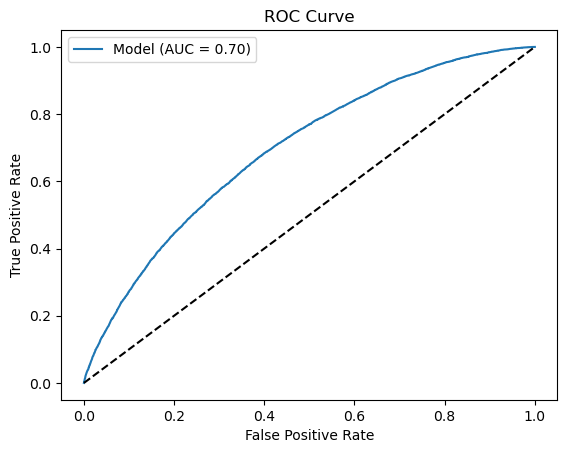

In [199]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

auc = roc_auc_score(df_clean['Default_Flag'], df_clean['PIT_PD'])
gini = (2 * auc) - 1

print(f"AUC-ROC Score: {auc:.4f}")
print(f"Gini Coefficient: {gini:.4f}")

fpr, tpr, thresholds = roc_curve(df_clean['Default_Flag'], df_clean['PIT_PD'])
plt.plot(fpr, tpr, label=f'Model (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--') # Random line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [215]:

train_probs = result.predict(X_train_sm)
test_probs = result.predict(X_test_sm)

auc_train = roc_auc_score(y_train, train_probs)
auc_test = roc_auc_score(y_test, test_probs)

print(f"--- PERFORMANCE VALIDATION ---")
print(f"Train AUC: {auc_train:.4f}")
print(f"Test AUC:  {auc_test:.4f}")
print(f"Gini (Test): {(2 * auc_test - 1):.4f}")

--- PERFORMANCE VALIDATION ---
Train AUC: 0.6974
Test AUC:  0.6900
Gini (Test): 0.3800


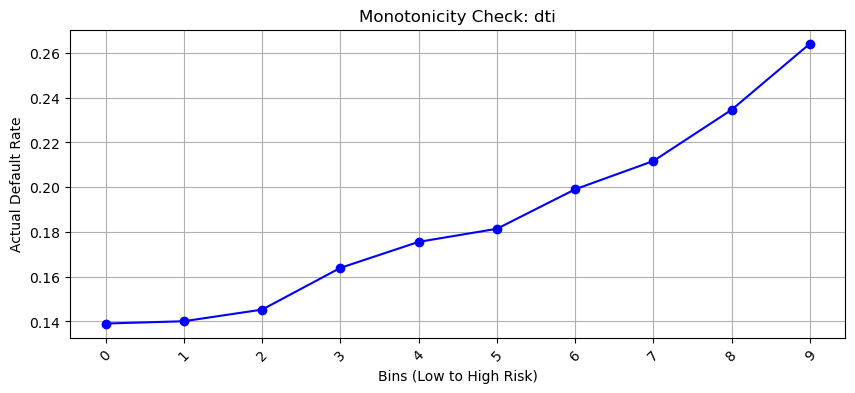

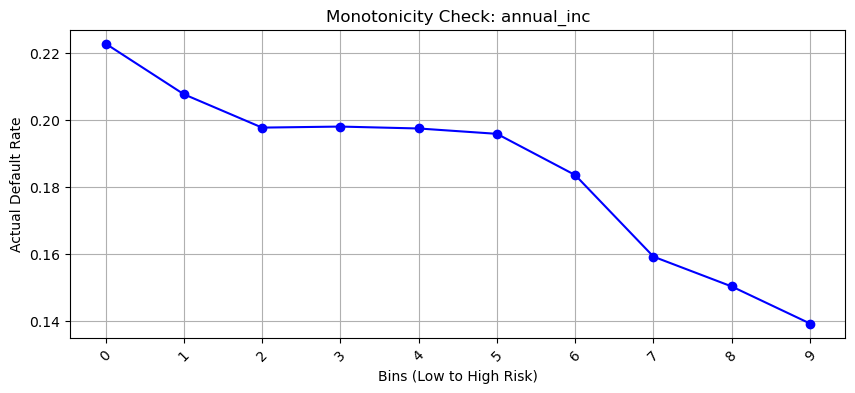

In [214]:
import matplotlib.pyplot as plt

def check_monotonicity(var_name, woe_tables):
    table = woe_tables[var_name].copy()
    table = table.sort_index()
    table['Event_Rate'] = table['Events'] / table['Total']
    
    plt.figure(figsize=(10, 4))
    plt.plot(table.index.astype(str), table['Event_Rate'], marker='o', linestyle='-', color='b')
    plt.title(f'Monotonicity Check: {var_name}')
    plt.xlabel('Bins (Low to High Risk)')
    plt.ylabel('Actual Default Rate')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.show()
check_monotonicity('dti', woe_tables)
check_monotonicity('annual_inc', woe_tables)

In [204]:
from statsmodels.stats.outliers_influence import variance_inflation_factor


X = df_clean[woe_feature_cols]
X_vif = sm.add_constant(X)

vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]

print(vif_data.sort_values(by="VIF", ascending=False))

              feature       VIF
1       grade_idx_woe  1.346551
2  fico_range_low_woe  1.240463
5      annual_inc_woe  1.127492
3             dti_woe  1.093789
4  home_ownership_woe  1.070209
0               const  1.050874
6         purpose_woe  1.050188


In [201]:
from sklearn.metrics import brier_score_loss

# Brier Score
brier = brier_score_loss(df_clean['Default_Flag'], df_clean['PIT_PD'])
print(f"Brier Score: {brier:.4f}")

# E/A Ratio
expected_defaults = df_clean['PIT_PD'].sum()
actual_defaults = df_clean['Default_Flag'].sum()
ea_ratio = expected_defaults / actual_defaults
print(f"E/A Ratio: {ea_ratio:.4f}")

Brier Score: 0.1398
E/A Ratio: 1.0095
